In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sorted_portfolios import get_sorted_index, get_sorted_portfolio
from utils import *
from signals import *
from visualization import plot_group_cum, plot_solo_cum

plt.style.use("default")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# CRSP data
crsp = pd.read_csv("csrp_msf.csv", index_col=0)
# Construct dfs
dfs = {}
dfs['prc'] = np.abs(date_cusip_pivot(crsp, 'prc_adj'))
dfs['vol'] = date_cusip_pivot(crsp, 'vol')
dfs['ret'] = get_simple_ret(dfs['prc'])
vol_q = np.nanquantile(dfs['vol'], .7, axis=1,).reshape(-1, 1)
dfs['idx_vol_threshold'] = create_empty_df(dfs['ret'])
dfs['idx_vol_threshold'][dfs['vol'] >= vol_q] = 1

In [3]:
# Price momentum
dfs['mom_prc'] = get_momentum(dfs['ret'], 12, 1)

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


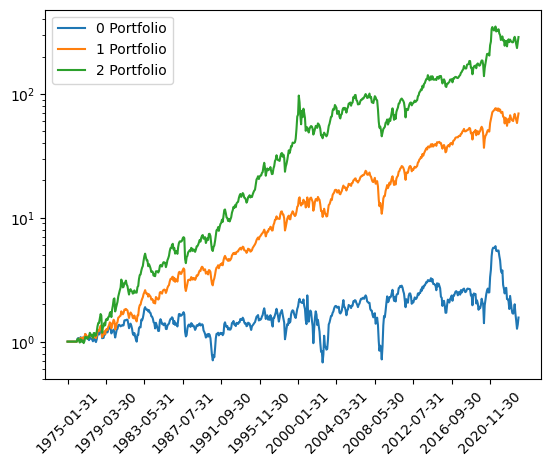

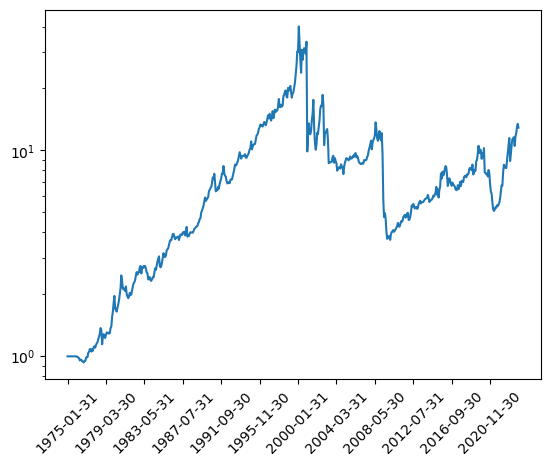

In [4]:
# Portfolio
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index
    (dfs['mom_prc'] * dfs['idx_vol_threshold'],
     quantiles=np.array([0.3, 0.7])
     ),
    
)

## Comp Funda

In [61]:
comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})
comp_funda_og['cusip'] = comp_funda_og['cusip'].apply(lambda x: str(x)[:8])
comp_funda_og = comp_funda_og[comp_funda_og.datafmt == 'STD']
comp_funda_og = comp_funda_og[~(comp_funda_og.cusip == "nan")].reset_index(drop=True)
comp_funda_og['date'] = pd.to_datetime(comp_funda_og.date)

C:\Users\Admin\AppData\Local\Temp\ipykernel_22072\2148792859.py:1: DtypeWarning: Columns (9,11,12,13,17,18,23,27,31,34,35,36,921,947,948) have mixed types. Specify dtype option on import or set low_memory=False.
  comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})


In [74]:
def exclude_short_records(group, years=2):
    temp = group.sort_values("date").reset_index(drop=True)
    if (temp.loc[temp.shape[0]-1, 'date'] - temp.loc[0, 'date']).days / 365 < 2:
        return create_empty_df(group)
    return group

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


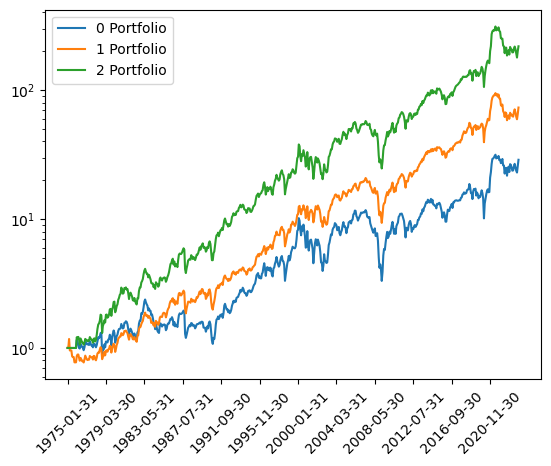

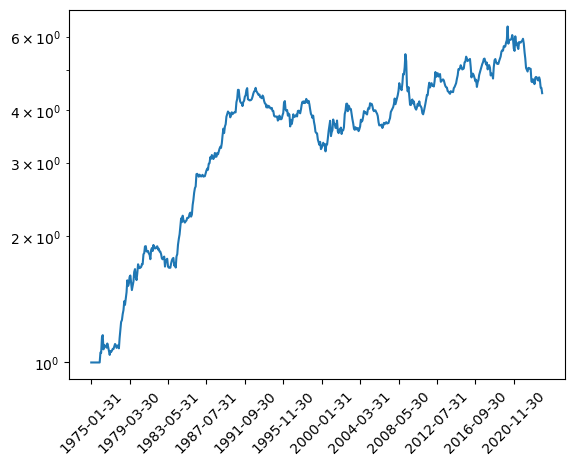

In [11]:
# Portfolio
dfs['pm_pct'] = get_pm_pct_df(comp_funda_og, dfs['ret'])
feature = 'pm_pct'
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs[feature] * dfs['idx_vol_threshold'], 
        quantiles=np.array([0.3, 0.7])
        )
)

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


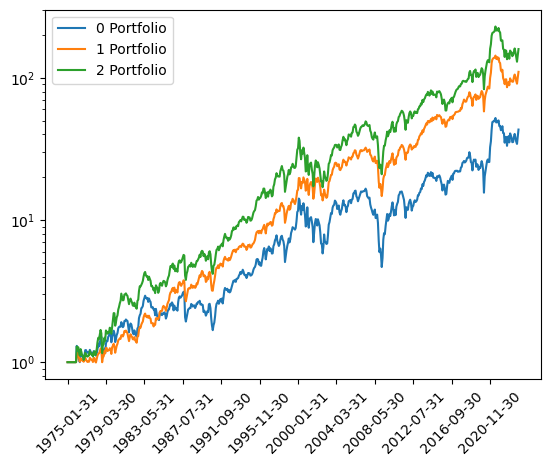

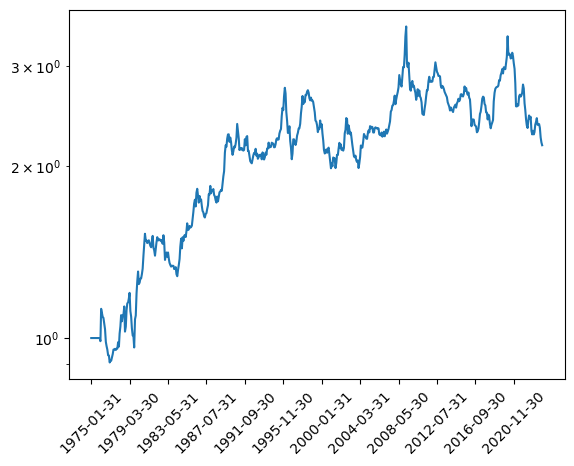

In [12]:
# Portfolio
dfs['eps_pct'] = get_eps_pct_df(comp_funda_og, dfs['ret'], )
feature = 'eps_pct'
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs[feature] * dfs['idx_vol_threshold'], 
        quantiles=np.array([0.3, 0.7])
        )
)

In [40]:
crsp['me'] = crsp.eval("prc * shrout")

In [43]:
dfs['size'] = date_cusip_pivot(crsp, "me")

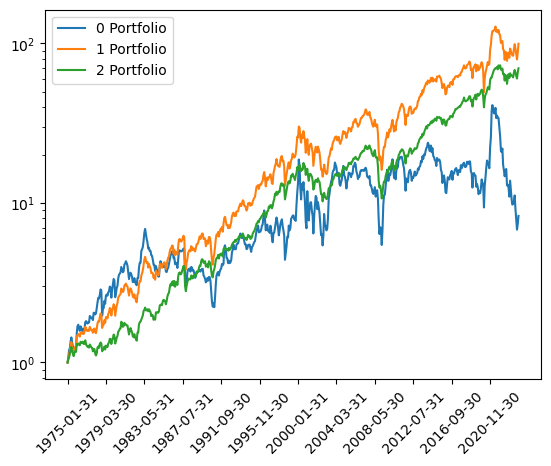

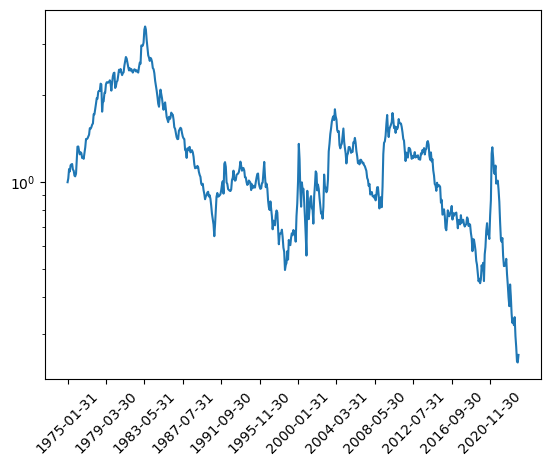

In [45]:
feature = 'size'
size_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs['size'] * dfs['idx_vol_threshold'],
        quantiles=np.array([0.3, 0.7])
        ),
    high_minus_low=False
)

In [56]:
ff_size = pd.read_csv("Portfolios_Formed_on_ME.CSV", index_col=0) / 100
ff_size = ff_size[['Lo 30', 'Med 40', 'Hi 30']]
ff_size = ff_size[(ff_size.index >= 197501) & (ff_size.index <= 202011)]

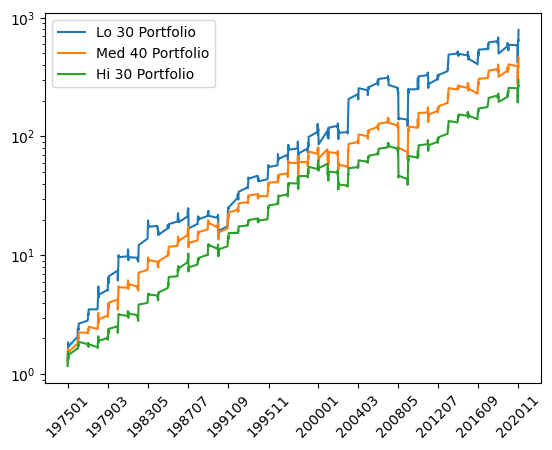

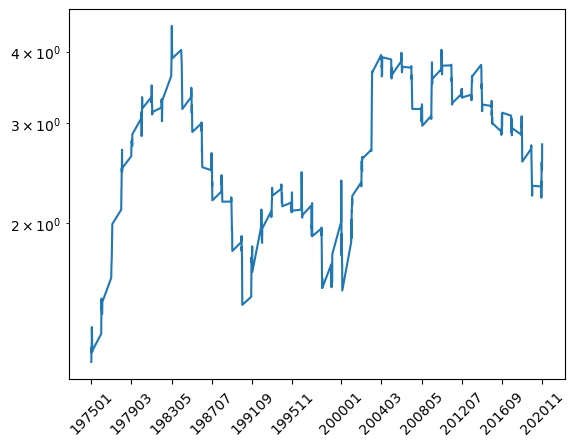

In [58]:
plot_group_cum(ff_size)
plot_solo_cum(ff_size.iloc[:, 0] - ff_size.iloc[:, -1])